In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [122]:
test=pd.read_csv('/content/test.csv')
train=pd.read_csv('/content/train.csv')
test

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1
...,...,...,...,...,...,...,...,...,...,...,...,...
254564,848558,92835.97,0.068,744,29704.00,13.48,Female,Single,Bachelor's,Employed,Debt consolidation,B2
254565,848559,48846.47,0.091,634,20284.33,9.58,Female,Married,High School,Employed,Debt consolidation,D4
254566,848560,20668.52,0.096,718,26387.55,9.00,Male,Single,Master's,Employed,Debt consolidation,C4
254567,848561,34105.09,0.094,739,11107.36,9.81,Male,Single,Bachelor's,Employed,Business,C2


In [123]:
train

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


In [124]:
#preprocessing
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [125]:
train['marital_status'].value_counts()

,count
marital_status,
Single,288843
Married,277239
Divorced,21312
Widowed,6600


In [126]:
train['gender'].value_counts()

,count
gender,
Female,306175
Male,284091
Other,3728


In [127]:
train['education_level'].value_counts()

,count
education_level,
Bachelor's,279606
High School,183592
Master's,93097
Other,26677
PhD,11022


In [128]:
train['employment_status'].value_counts()

,count
employment_status,
Employed,450645
Unemployed,62485
Self-employed,52480
Retired,16453
Student,11931


In [129]:
train['loan_paid_back'].value_counts()

,count
loan_paid_back,
1.0,474494
0.0,119500


In [130]:
train['loan_purpose'].value_counts()

,count
loan_purpose,
Debt consolidation,324695
Other,63874
Car,58108
Home,44118
Education,36641
Business,35303
Medical,22806
Vacation,8449


In [131]:
train['grade_subgrade'].value_counts()

,count
grade_subgrade,
C3,58695
C4,55957
C2,54443
C1,53363
C5,53317
D1,37029
D3,36694
D4,35097
D2,34432


In [132]:
train['marital_status']=train['marital_status'].astype('category')
train['gender']=train['gender'].astype('category')
train['education_level']=train['education_level'].astype('category')
train['employment_status']=train['employment_status'].astype('category')
train['loan_paid_back']=train['loan_paid_back'].astype('bool')
train['loan_purpose']=train['loan_purpose'].astype('category')
train['grade_subgrade']=train['grade_subgrade'].astype('category')

In [133]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   id                    593994 non-null  int64   
 1   annual_income         593994 non-null  float64 
 2   debt_to_income_ratio  593994 non-null  float64 
 3   credit_score          593994 non-null  int64   
 4   loan_amount           593994 non-null  float64 
 5   interest_rate         593994 non-null  float64 
 6   gender                593994 non-null  category
 7   marital_status        593994 non-null  category
 8   education_level       593994 non-null  category
 9   employment_status     593994 non-null  category
 10  loan_purpose          593994 non-null  category
 11  grade_subgrade        593994 non-null  category
 12  loan_paid_back        593994 non-null  bool    
dtypes: bool(1), category(6), float64(4), int64(2)
memory usage: 31.2 MB


In [134]:
train.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

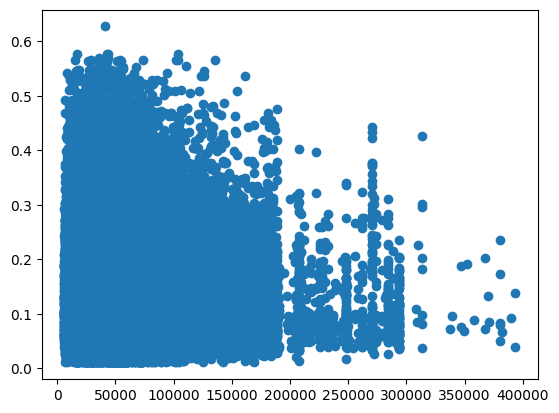

In [135]:
#eda
plt.scatter(train['annual_income'],train['debt_to_income_ratio'])


In [136]:
train.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345
std,171471.442235,26711.942078,0.068573,55.424956,6926.530568,2.008959
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000


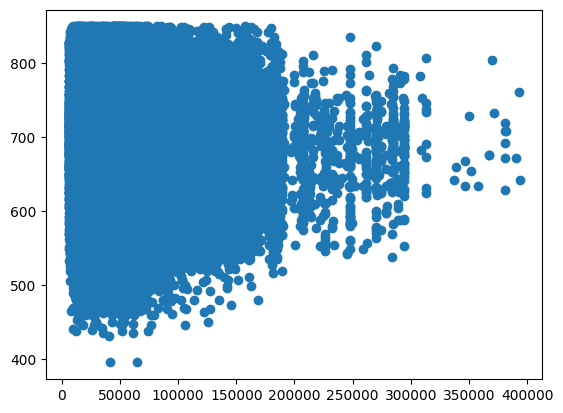

In [137]:
plt.scatter(train['annual_income'],train['credit_score'])

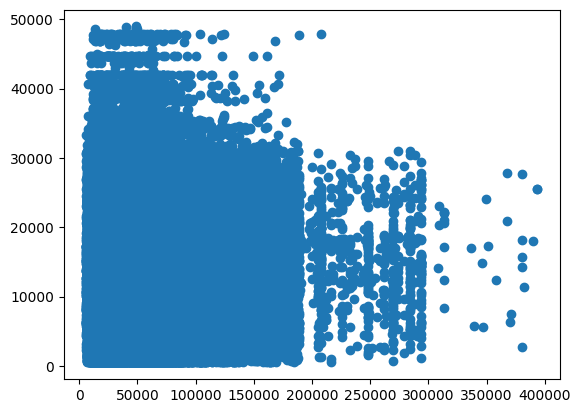

In [138]:
plt.scatter(train['annual_income'],train['loan_amount'])

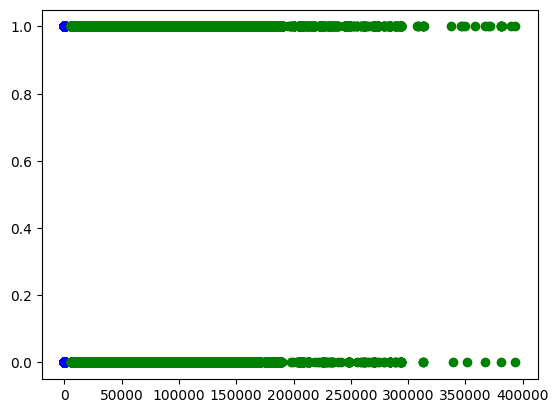

In [139]:
plt.scatter(train['credit_score'],train['loan_paid_back'],color='red')
plt.scatter(train['interest_rate'],train['loan_paid_back'],color='blue')
plt.scatter(train['annual_income'],train['loan_paid_back'],color='green')

In [140]:
train['loan_paid_back'].value_counts(normalize=True)

,proportion
loan_paid_back,
True,0.79882
False,0.20118


In [141]:
train.groupby('loan_paid_back')[['annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate']].agg(["mean",'max','min',"std"])

annual_income                                    \
                        mean        max      min           std   
loan_paid_back                                                   
False           47875.503881  393381.74  6098.80  27199.060946   
True            48296.999711  393064.03  6002.43  26587.212646   

               debt_to_income_ratio                         credit_score       \
                               mean    max    min       std         mean  max   
loan_paid_back                                                                  
False                      0.166564  0.627  0.011  0.083245   655.010628  849   
True                       0.109144  0.577  0.011  0.058975   687.440208  849   

                                 loan_amount                                 \
                min        std          mean       max     min          std   
loan_paid_back                                                                
False           395  51.680938  15072.223883  48959.95  507.42  6945.374637   
True            395  54.418255  15007.220145  48954.70  500.09  6921.722581   

               interest_rate                         
                        mean    max   min       std  
loan_paid_back                                       
False              12.881495  20.99  3.89  1.981273  
True               12.224088  20.84  3.20  1.994191

In [142]:
pd.crosstab(train['gender'],train['loan_paid_back'])

loan_paid_back,False,True
gender,,
Female,60712,245463
Male,58025,226066
Other,763,2965


In [143]:
pd.crosstab(train['gender'],train['loan_paid_back'],normalize='columns')

loan_paid_back,False,True
gender,,
Female,0.508050,0.517315
Male,0.485565,0.476436
Other,0.006385,0.006249


In [144]:
pd.crosstab(train['marital_status'],train['loan_paid_back'],normalize='columns')

loan_paid_back,False,True
marital_status,,
Divorced,0.036268,0.035781
Married,0.465983,0.466927
Single,0.486142,0.486305
Widowed,0.011607,0.010986


In [145]:
pd.crosstab(train['education_level'],train['loan_paid_back'],normalize='columns')

loan_paid_back,False,True
education_level,,
Bachelor's,0.493950,0.464872
High School,0.292368,0.313290
Master's,0.153983,0.157422
Other,0.044025,0.045134
PhD,0.015674,0.019282


In [146]:
pd.crosstab(train['employment_status'],train['loan_paid_back'],normalize='columns')
#seems most relevant out of all features

loan_paid_back,False,True
employment_status,,
Employed,0.399188,0.849204
Retired,0.000385,0.034578
Self-employed,0.044594,0.099371
Student,0.073531,0.006626
Unemployed,0.482301,0.010221


In [147]:
pd.crosstab(train['employment_status'],train['loan_paid_back'],normalize='index')

loan_paid_back,False,True
employment_status,,
Employed,0.105855,0.894145
Retired,0.002796,0.997204
Self-employed,0.101543,0.898457
Student,0.736485,0.263515
Unemployed,0.922381,0.077619


In [148]:
pd.crosstab(train['loan_purpose'],train['loan_paid_back'],normalize='columns')

loan_paid_back,False,True
loan_purpose,,
Business,0.055213,0.060496
Car,0.096946,0.098048
Debt consolidation,0.551816,0.545324
Education,0.068360,0.060005
Home,0.065264,0.076543
Medical,0.042351,0.037398
Other,0.105632,0.108012
Vacation,0.014418,0.014175


In [149]:
grade_subgrade_nc=pd.crosstab(train['grade_subgrade'],train['loan_paid_back'],normalize='columns')

In [150]:
grade_subgrade_nc=grade_subgrade_nc.reset_index()
grade_subgrade_nc

loan_paid_back,grade_subgrade,False,True
0,A1,0.000636,0.003212
1,A2,0.000795,0.004053
2,A3,0.000770,0.004160
3,A4,0.000611,0.003431
4,A5,0.001138,0.004921
5,B1,0.010042,0.027701
6,B2,0.007941,0.029965
7,B3,0.006987,0.027589
8,B4,0.007925,0.027250
9,B5,0.007674,0.027440


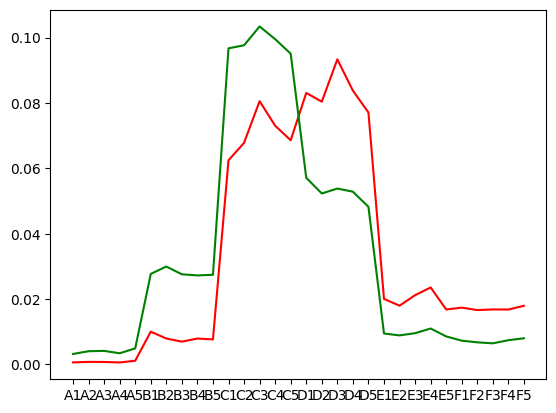

In [151]:
plt.plot(grade_subgrade_nc["grade_subgrade"],grade_subgrade_nc[False],color="red")
plt.plot(grade_subgrade_nc["grade_subgrade"],grade_subgrade_nc[True],color="green")

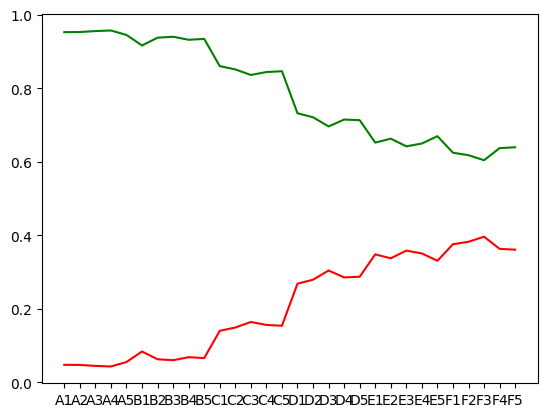

In [152]:
grade_subgrade_ni=pd.crosstab(train['grade_subgrade'],train['loan_paid_back'],normalize='index')
grade_subgrade_ni=grade_subgrade_ni.reset_index()
plt.plot(grade_subgrade_ni["grade_subgrade"],grade_subgrade_ni[False],color="red")
plt.plot(grade_subgrade_ni["grade_subgrade"],grade_subgrade_ni[True],color="green")


In [153]:
train.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

In [154]:
#first doing using train_test_split (for practice)

y=train['loan_paid_back']
dropped_features=['gender', 'marital_status','loan_paid_back','id']
X=train.drop(dropped_features,axis=1)

In [155]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42,stratify=y)


In [156]:
y_train.value_counts(normalize=True)

,proportion
loan_paid_back,
True,0.798819
False,0.201181


In [157]:
num_cols=['annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate']
ohcat_cols=['employment_status', 'loan_purpose']
ocat_cols=['education_level', 'grade_subgrade']

In [158]:
X_train

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,education_level,employment_status,loan_purpose,grade_subgrade
17160,43447.66,0.058,623,13174.23,12.52,Bachelor's,Unemployed,Business,D4
181688,61173.86,0.123,628,32037.36,12.66,Bachelor's,Employed,Other,D1
529453,38228.49,0.085,619,28884.28,12.08,Bachelor's,Self-employed,Debt consolidation,D2
362449,62828.38,0.290,679,24359.66,9.68,Master's,Student,Car,C3
57470,35604.48,0.099,719,7100.39,12.91,Other,Unemployed,Debt consolidation,C5
...,...,...,...,...,...,...,...,...,...
201057,51936.68,0.092,658,12452.28,10.09,Bachelor's,Employed,Debt consolidation,D2
289126,123901.71,0.090,709,20772.37,11.09,High School,Employed,Medical,C5
445232,49500.58,0.097,704,7069.42,13.28,High School,Employed,Debt consolidation,C2
11972,73813.12,0.050,673,13923.13,14.02,High School,Employed,Car,C4


In [159]:
#planned work flow:
'''
1. try using train test split then switch to cross validation
2. algos to try:
  1. logistic regression
  2. SVM
  3. DT
  4. Random Forest-> XGboost
'''

'\n1. try using train test split then switch to cross validation\n2. algos to try:\n  1. logistic regression\n  2. SVM\n  3. DT\n  4. Random Forest-> XGboost\n'

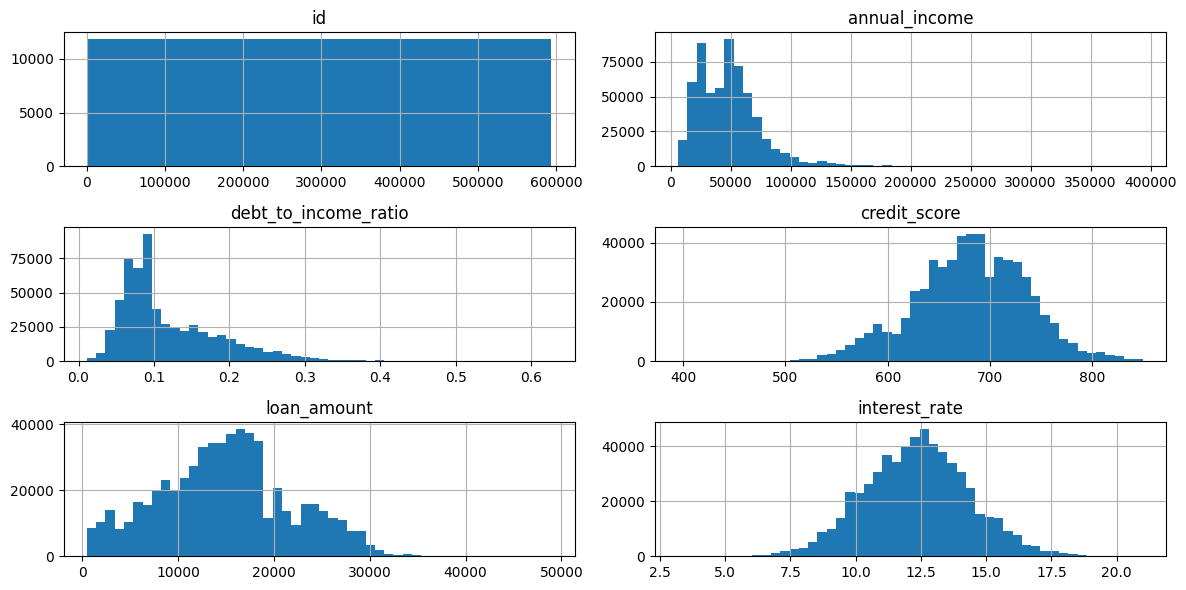

In [160]:
train.hist(figsize=(12,6),bins=50)
plt.tight_layout()

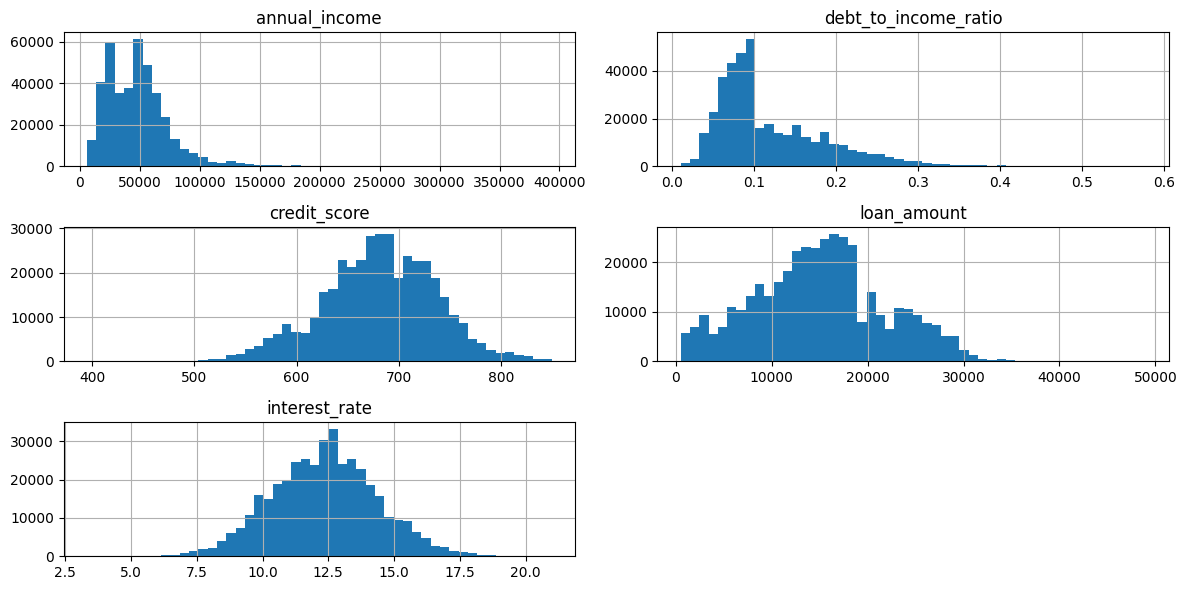

In [161]:
X_train.hist(figsize=(12,6),bins=50)
plt.tight_layout()

In [162]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])
X_train.join(y_train).groupby('loan_paid_back')[['annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate']].agg(["mean",'max','min',"std"])

annual_income                                 \
                        mean        max       min       std   
loan_paid_back                                                
False              -0.011340  12.903512 -1.574810  1.019996   
True                0.002856  12.891635 -1.578413  0.994884   

               debt_to_income_ratio                                \
                               mean       max       min       std   
loan_paid_back                                                      
False                      0.669548  6.665791 -1.600951  1.212118   
True                      -0.168624  6.665791 -1.600951  0.860521   

               credit_score                               loan_amount  \
                       mean       max       min       std        mean   
loan_paid_back                                                          
False             -0.464399  3.035677 -5.163066  0.932886    0.006990   
True               0.116958  3.035677 -5.163066  0.982182   -0.001761   

                                             interest_rate            \
                     max       min       std          mean       max   
loan_paid_back                                                         
False           4.898575 -2.095174  1.002526      0.260882  4.298534   
True            4.897817 -2.096198  0.999358     -0.065703  4.223836   

                                    
                     min       std  
loan_paid_back                      
False          -4.217044  0.986786  
True           -4.500896  0.992552

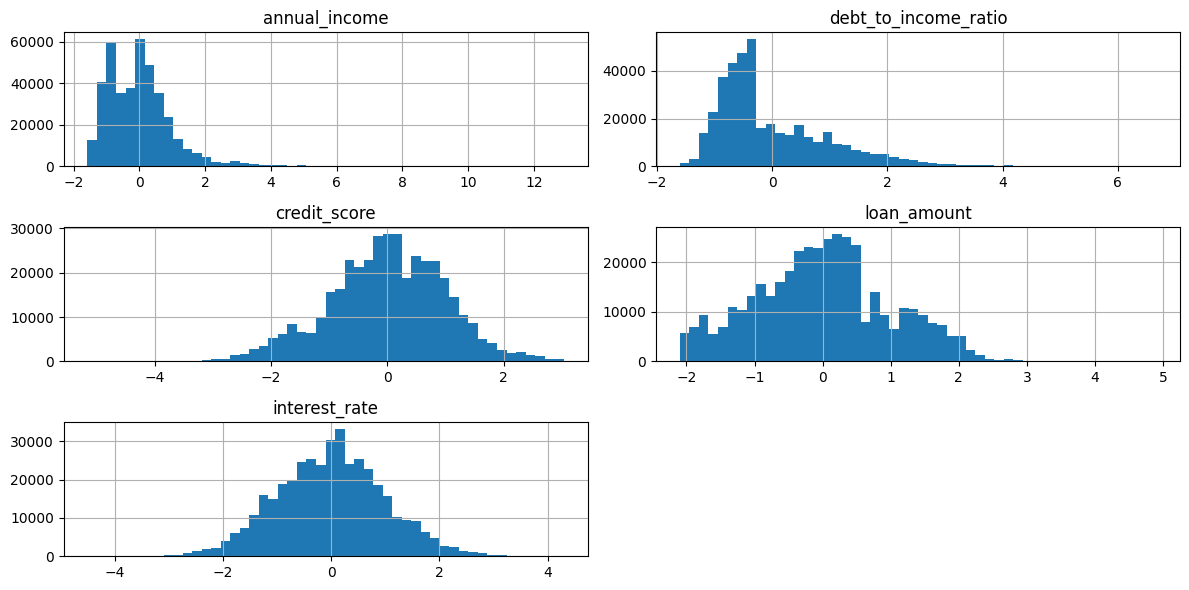

In [163]:
X_train.hist(figsize=(12,6),bins=50)
plt.tight_layout()

In [164]:
#trying the minmaxscaling
'''from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])
X_train.join(y_train).groupby('loan_paid_back')[['annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate']].agg(["mean",'max','min',"std"])'''
#roc scores with this were very slightly worse


'from sklearn.preprocessing import MinMaxScaler\nscaler=MinMaxScaler()\nX_train[num_cols]=scaler.fit_transform(X_train[num_cols])\nX_test[num_cols]=scaler.transform(X_test[num_cols])\nX_train.join(y_train).groupby(\'loan_paid_back\')[[\'annual_income\', \'debt_to_income_ratio\', \'credit_score\',\n       \'loan_amount\', \'interest_rate\']].agg(["mean",\'max\',\'min\',"std"])'

In [165]:
print(train['education_level'].value_counts())
print(train['grade_subgrade'].value_counts().sort_index().index)

education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64
CategoricalIndex(['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5',
                  'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5',
                  'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5'],
                 categories=['A1', 'A2', 'A3', 'A4', ..., 'F2', 'F3', 'F4', 'F5'], ordered=False, dtype='category', name='grade_subgrade')


In [166]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder

ohencoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
oencoder=OrdinalEncoder(categories=[['Other','High School',"Bachelor's","Master's","PhD"],['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5','C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5','E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5']])

train_ohencoded_values=ohencoder.fit_transform(X_train[ohcat_cols])
test_ohencoded_values=ohencoder.transform(X_test[ohcat_cols])
new_ohcols=ohencoder.get_feature_names_out(ohcat_cols)

X_train[ocat_cols]=oencoder.fit_transform(X_train[ocat_cols])
X_test[ocat_cols]=oencoder.transform(X_test[ocat_cols])


In [167]:
train_ohencoded_df=pd.DataFrame(train_ohencoded_values,columns=new_ohcols,index=X_train.index)
test_ohencoded_df=pd.DataFrame(test_ohencoded_values,columns=new_ohcols,index=X_test.index)

prep_X_train=pd.concat([X_train.drop(columns=ohcat_cols),train_ohencoded_df],axis=1)
prep_X_test=pd.concat([X_test.drop(columns=ohcat_cols),test_ohencoded_df],axis=1)

In [172]:
prep_X_test

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,education_level,grade_subgrade,employment_status_Employed,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation
319418,1.355780,-0.680801,-0.359397,-0.798054,0.329577,2.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
99086,-0.541331,-0.578562,-0.052396,0.017011,-0.671376,2.0,10.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34048,1.662907,0.370799,1.861848,1.928581,-0.073792,2.0,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
132876,0.795437,-0.753829,-0.720576,0.177282,-0.277967,2.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
109395,0.900551,1.028048,0.995020,0.478881,0.852464,2.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99522,0.129715,0.137110,0.868608,-0.425908,-0.347685,2.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
304827,-0.615224,-0.812251,-0.142691,0.366479,-1.169363,3.0,10.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
583948,0.409294,-0.826857,-1.551285,0.933193,0.434155,2.0,20.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
131874,0.138968,-0.695407,-1.551285,1.166723,0.947081,1.0,24.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [168]:
#first using logistic regression

from sklearn.linear_model import LogisticRegression

LogReg=LogisticRegression()
LogReg.fit(prep_X_train,y_train)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score

y_pred=LogReg.predict(prep_X_test)
y_pred_proba=LogReg.predict_proba(prep_X_test)[:,1]
print("accuracy: " ,  accuracy_score(y_test,y_pred))
print("confusion matrix: " , confusion_matrix(y_test,y_pred))
print("classification report: ", classification_report(y_test,y_pred))
print("ROC AUC: " ,  roc_auc_score(y_test,y_pred_proba))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


accuracy:  0.8990914146077676
confusion matrix:  [[ 23872  15563]
 [  4217 152367]]
classification report:                precision    recall  f1-score   support

       False       0.85      0.61      0.71     39435
        True       0.91      0.97      0.94    156584

    accuracy                           0.90    196019
   macro avg       0.88      0.79      0.82    196019
weighted avg       0.90      0.90      0.89    196019

ROC AUC:  0.9098645907223313


In [169]:
#experimenting with some tuning

LogReg=LogisticRegression(class_weight="balanced")
LogReg.fit(prep_X_train,y_train)

y_pred=LogReg.predict(prep_X_test)
y_pred_proba=LogReg.predict_proba(prep_X_test)[:,1]
print("accuracy: " ,  accuracy_score(y_test,y_pred))
print("confusion matrix: " , confusion_matrix(y_test,y_pred))
print("classification report: ", classification_report(y_test,y_pred))
print("ROC AUC: " ,  roc_auc_score(y_test,y_pred_proba))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


accuracy:  0.8602431396956417
confusion matrix:  [[ 30208   9227]
 [ 18168 138416]]
classification report:                precision    recall  f1-score   support

       False       0.62      0.77      0.69     39435
        True       0.94      0.88      0.91    156584

    accuracy                           0.86    196019
   macro avg       0.78      0.82      0.80    196019
weighted avg       0.87      0.86      0.87    196019

ROC AUC:  0.9099672233191702


In [170]:
LogReg=LogisticRegression(class_weight="balanced",max_iter=10000)
LogReg.fit(prep_X_train,y_train)

y_pred=LogReg.predict(prep_X_test)
y_pred_proba=LogReg.predict_proba(prep_X_test)[:,1]
print("accuracy: " ,  accuracy_score(y_test,y_pred))
print("confusion matrix: " , confusion_matrix(y_test,y_pred))
print("classification report: ", classification_report(y_test,y_pred))
print("ROC AUC: " ,  roc_auc_score(y_test,y_pred_proba))

accuracy:  0.8602278350568057
confusion matrix:  [[ 30219   9216]
 [ 18182 138402]]
classification report:                precision    recall  f1-score   support

       False       0.62      0.77      0.69     39435
        True       0.94      0.88      0.91    156584

    accuracy                           0.86    196019
   macro avg       0.78      0.83      0.80    196019
weighted avg       0.87      0.86      0.87    196019

ROC AUC:  0.909971196669277
